In [61]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape
from evoscape.jax.experiment import Experiment
from evoscape.jax.dynamics import state_probs

plt.style.use("default")

In [62]:
modules = (
    Node(x=1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
    Node(x=-2.5, y=-1.0, a=np.array([1.5]), s=np.array([1.0])),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

experiment = Experiment(landscape)

n_cells = 200
q0 = np.vstack((
    np.linspace(-1, 1, n_cells),
    np.ones(n_cells),
))

experiment.set_initial_conditions(q0)
experiment.set_regime_params()
experiment.set_state_probs(state_probs)
experiment.set_simulation(n=n_cells, cell_noise=0.2, t0=0.0, tf=10.0, nt=10, ndt=50, noise=0.2)

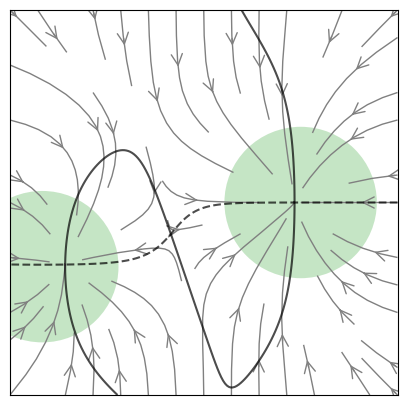

In [63]:

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

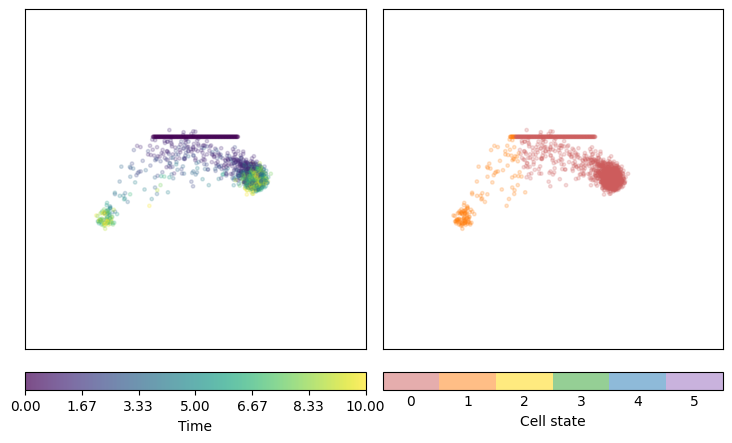

In [64]:
traj, states, t0, tf, nt = experiment.get_trajectory()
fig = plot_traj(traj, states, t0, tf, nt, L=4)
plt.show()

In [65]:
np.mean(states[:, :, -1], axis=1)

Array([0.9201532 , 0.07984679], dtype=float32)

Train step 0 : Loss = 0.09027263522148132
Train step 5 : Loss = 0.1959679126739502
Train step 10 : Loss = 0.04299566149711609
Train step 15 : Loss = 0.031770914793014526
Train step 20 : Loss = 0.17368468642234802
Train step 25 : Loss = 0.09894189238548279
Train step 30 : Loss = 0.03516364097595215
Train step 35 : Loss = 0.06990349292755127
Train step 40 : Loss = 0.27263665199279785
Train step 45 : Loss = 0.42903944849967957
Train step 50 : Loss = 0.05245736241340637
Train step 55 : Loss = 0.09384866058826447
Train step 60 : Loss = 0.22476987540721893
Train step 65 : Loss = 0.6019816398620605
Train step 70 : Loss = 0.6019840240478516
Train step 75 : Loss = 0.6019845008850098
Train step 80 : Loss = 0.6019848585128784
Train step 85 : Loss = 0.601984977722168
Train step 90 : Loss = 0.6019852161407471
Train step 95 : Loss = 0.6019850969314575
Landscape with modules:
Node: x=2.405576467514038; y=-0.5814028382301331; a=[1.4039623]; s=[0.16691342],
Node: x=-1.6183409690856934; y=0.245435088872

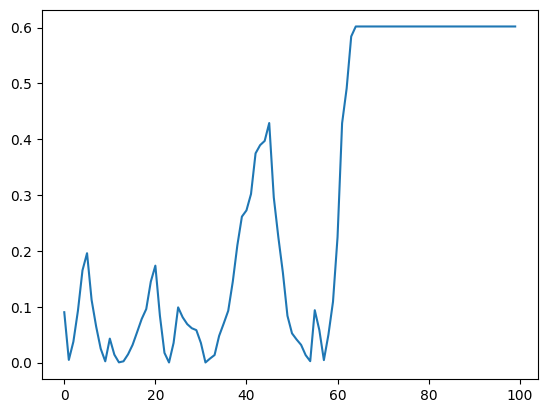

In [66]:
from evoscape.jax.losses import biseparating_fitness

def user_fitness(traj, states, dynamic, fitness_params):
    final_states = jnp.mean(states[:, :, -1], axis=1) # avg over cells

    # using target proportion 75% / 25%
    proportion_loss = jnp.sum((final_states - jnp.array((0.75, 0.25))) ** 2)

    return proportion_loss

opt = optax.adam(0.1)

losses = experiment.optimize(biseparating_fitness, fitness_params=(1., 1., 0., [0.7, 0.3]), steps=100, optimizer=opt)
optimized_landscape = experiment.get_landscape()

plt.plot(losses)
print(optimized_landscape)

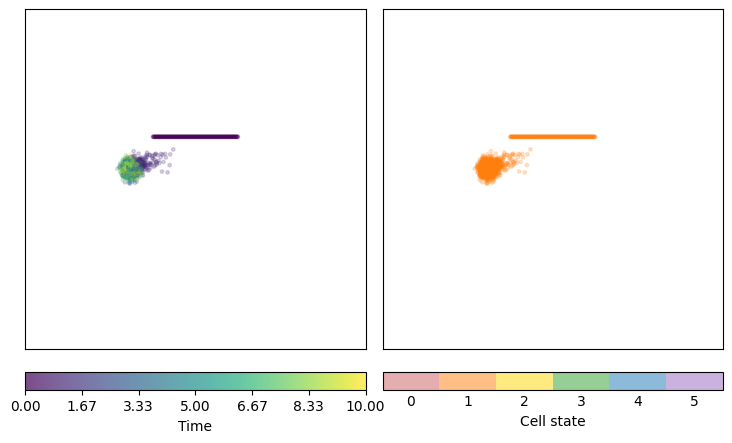

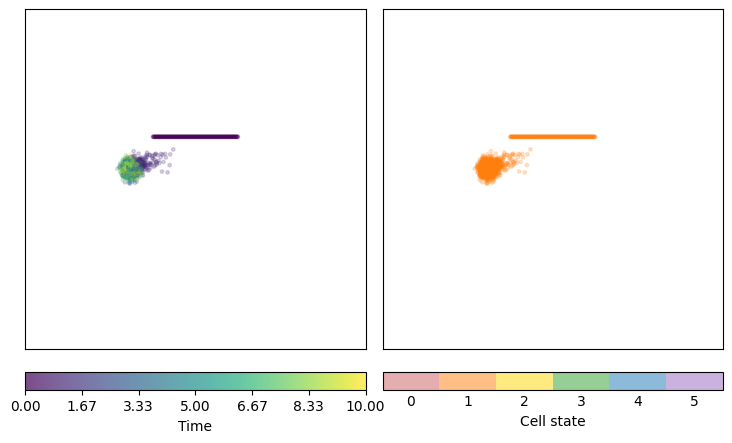

In [67]:
traj, states, t0, tf, nt = experiment.get_trajectory()
fig = plot_traj(traj, states, t0, tf, nt, L=4)
fig

In [68]:
np.mean(states[:, :, -1], axis=1)

Array([0., 1.], dtype=float32)

Landscape with modules:
Node: x=2.405576467514038; y=-0.5814028382301331; a=[1.4039623]; s=[0.16691342],
Node: x=-1.6183409690856934; y=0.24543508887290955; a=[1.995417]; s=[1.6291971]


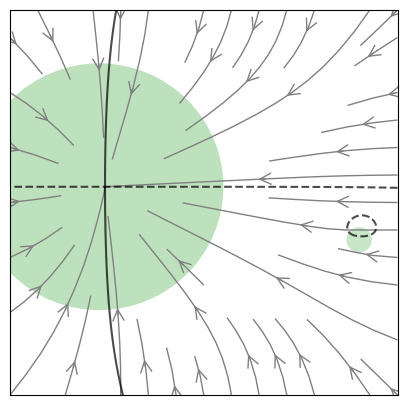

In [69]:
l = experiment.get_landscape()


print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')